<a href="https://colab.research.google.com/github/harsh2810dev/data-science-assignment/blob/main/harsh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving imdb_data (1).csv to imdb_data (1).csv


In [ ]:
import pandas as pd
import json
import numpy as np
from collections import Counter
import warnings
import ast # Import the ast module
warnings.filterwarnings('ignore')
# LOAD DATA
print("Loading imdb_data (1).csv...")
df = pd.read_csv('imdb_data (1).csv')
# HELPER: Parse JSON columns
def parse_json(x):
    try:
        # Use ast.literal_eval to safely parse string representations of Python literals
        return ast.literal_eval(x) if pd.notna(x) and x != '' else []
    except Exception as e:
        print(f"Error parsing: {x} - {e}") # Print the error for debugging
        return []
# PARSE COLUMNS
df['genres_parsed'] = df['genres'].apply(parse_json)
df['prod_companies'] = df['production_companies'].apply(parse_json)
df['cast_parsed'] = df['cast'].apply(parse_json)
df['crew_parsed'] = df['crew'].apply(parse_json)

# CREATE PROFIT & ROI
df['profit'] = df['revenue'] - df['budget']
df['roi'] = np.where(df['budget'] > 0, df['profit']/df['budget'], 0)
print(f" Dataset loaded: {df.shape[0]} movies\n")

Loading imdb_data (1).csv...
 Dataset loaded: 3000 movies



In [ ]:
df.shape

(3000, 29)

**QUESTION 1**


**Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.**


In [ ]:
# Highest profit movie
highest_profit_idx = df["profit"].idxmax()
highest_profit_movie = df.iloc[highest_profit_idx]
print("HIGHEST PROFIT MOVIE")
print(f"Title: {highest_profit_movie['title']}")
print(f"Profit: ${highest_profit_movie['profit']:,.0f}")
print(f"ROI: {highest_profit_movie['roi']:.2%}")
# Producers
producers = [comp['name'] for comp in highest_profit_movie["prod_companies"]]
print(f"\nProducers: {', '.join(producers)}")
# Director from crew
director = next((person['name'] for person in highest_profit_movie["crew_parsed"]
                if person.get('job') == 'Director'), 'N/A')
print(f"Director: {director}")
# Top 3 actors
actors = [person['name'] for person in highest_profit_movie["cast_parsed"][:3]]
print(f"Top Actors: {', '.join(actors)}")

HIGHEST PROFIT MOVIE
Title: Furious 7
Profit: $1,316,249,360
ROI: 692.76%

Producers: Universal Pictures, Original Film, Fuji Television Network, Dentsu, One Race Films, China Film Co., Québec Production Services Tax Credit, Media Rights Capital (MRC), Abu Dhabi Film Commission, Colorado Office of Film, Television & Media
Director: James Wan
Top Actors: Vin Diesel, Paul Walker, Dwayne Johnson


In [ ]:
import matplotlib.pyplot as plt

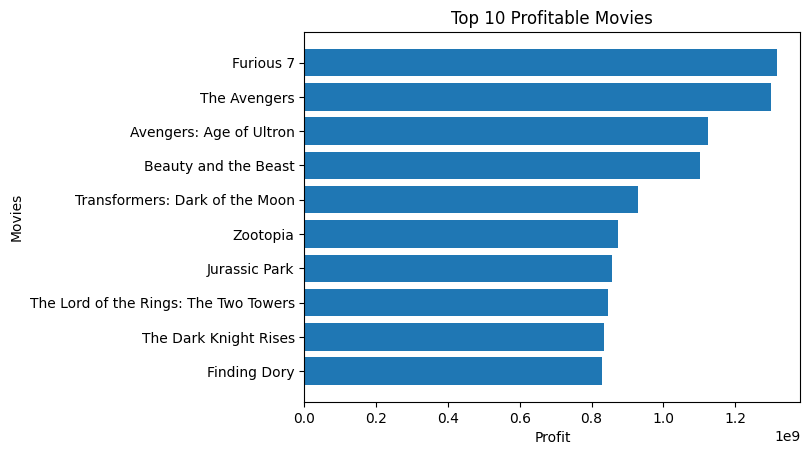

In [ ]:
top_profit_movies = df.sort_values(by="profit", ascending=False).head(10)

plt.figure()
plt.barh(top_profit_movies["title"], top_profit_movies["profit"])
plt.title("Top 10 Profitable Movies")
plt.xlabel("Profit")
plt.ylabel("Movies")
plt.gca().invert_yaxis()
plt.show()

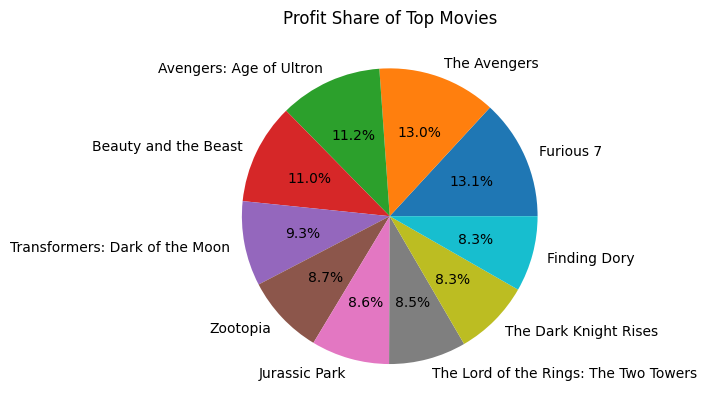

In [ ]:
plt.figure()
plt.pie(top_profit_movies["profit"], labels=top_profit_movies["title"], autopct='%1.1f%%')
plt.title("Profit Share of Top Movies")
plt.show()

**QUESTION 2**

**This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?**

In [ ]:
# Average ROI by language
lang_roi = df.groupby("original_language")["roi"].agg(['mean', 'count']).reset_index()
lang_roi = lang_roi[lang_roi['count'] >= 2]
lang_roi = lang_roi.sort_values("mean", ascending=False)
print("LANGUAGE WITH HIGHEST AVERAGE ROI")
print(lang_roi.head())
print(f"\n Winner: {lang_roi.iloc[0]['original_language']}")
print(f"Average ROI: {lang_roi.iloc[0]['mean']:.2%}")

LANGUAGE WITH HIGHEST AVERAGE ROI
   original_language           mean  count
18                ko  209986.756254     20
7                 en    4104.728457   2575
31                te       4.400768      2
24                pl       3.958170      2
19                ml       3.708333      2

 Winner: ko
Average ROI: 20998675.63%


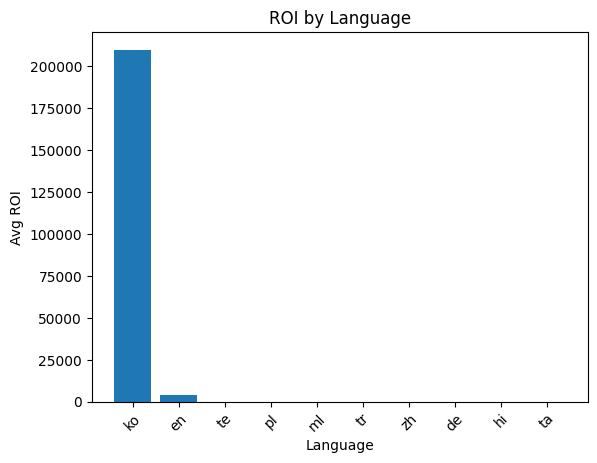

In [ ]:
import matplotlib.pyplot as plt
top_lang = lang_roi.head(10)

plt.figure()
plt.bar(top_lang["original_language"], top_lang["mean"])
plt.title("ROI by Language")
plt.xlabel("Language")
plt.ylabel("Avg ROI")
plt.xticks(rotation=45)
plt.show()

**QUESTION 3**

**Find out the unique genres of movies in this dataset.**

In [ ]:
all_genres = [g['name'] for genres in df['genres_parsed'] for g in genres]
unique_genres = sorted(list(set(all_genres)))
print(f"Total: {len(unique_genres)} genres")
print(unique_genres[:10], "...")  # First 10
print()

Total: 20 genres
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign'] ...



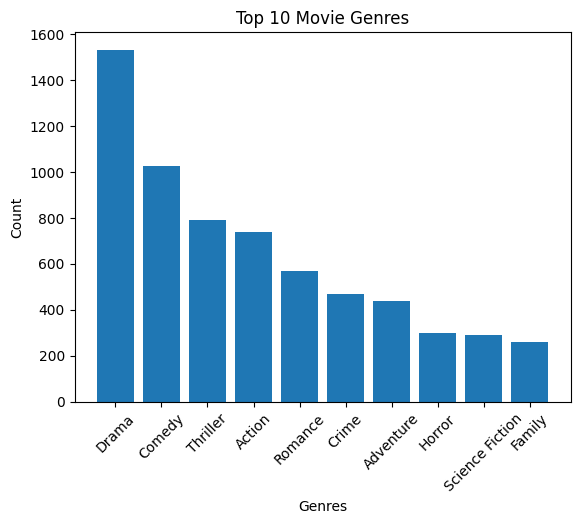

In [ ]:
# Count genre frequency
genre_counts = Counter(all_genres)
top_genres = dict(genre_counts.most_common(10))

plt.figure()
plt.bar(top_genres.keys(), top_genres.values())
plt.xlabel("Genres")
plt.ylabel("Count")
plt.title("Top 10 Movie Genres")
plt.xticks(rotation=45)
plt.show()

**QUESTION 4**

**Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?**

In [ ]:
# Extract producer names
df["producer_names"] = df["prod_companies"].apply(
    lambda x: [comp['name'] for comp in x]
)
# Table sample (first 5 movies)
table_sample = df[["title", "prod_companies", "crew_parsed", "roi"]].head()
print("Producer-Director Table (Sample):")
for idx, row in table_sample.iterrows():
    producers = [p['name'] for p in row["prod_companies"]]
    director = next((c['name'] for c in row["crew_parsed"] if c.get('job') == 'Director'), 'N/A')
    print(f"{row['title']}: Producers={producers[:2]}, Director={director}")
# Top 3 producers by average ROI
producer_roi = []
for idx, row in df.iterrows():
    for producer in row["producer_names"]:
        producer_roi.append({"producer": producer, "roi": row["roi"], "movie": row["title"]})

producer_df = pd.DataFrame(producer_roi)

print("\nTOP 3 PRODUCERS BY AVERAGE ROI:")
if not producer_df.empty:
    top_producers = (
        producer_df.groupby("producer")["roi"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(3)
    )
    for i, (producer, avg_roi) in enumerate(top_producers.items(), 1):
        print(f"{i}. {producer}: {avg_roi:.2%}")
else:
    print("No producer data found to calculate average ROI.")

Producer-Director Table (Sample):
Hot Tub Time Machine 2: Producers=['Paramount Pictures', 'United Artists'], Director=Steve Pink
The Princess Diaries 2: Royal Engagement: Producers=['Walt Disney Pictures'], Director=Garry Marshall
Whiplash: Producers=['Bold Films', 'Blumhouse Productions'], Director=Damien Chazelle
Kahaani: Producers=[], Director=Sujoy Ghosh
Marine Boy: Producers=[], Director=Jong-seok Yoon

TOP 3 PRODUCERS BY AVERAGE ROI:
1. Charles Chaplin Productions: 425000400.00%
2. Film It Suda: 209873781.25%
3. Lions Gate: 99999900.00%


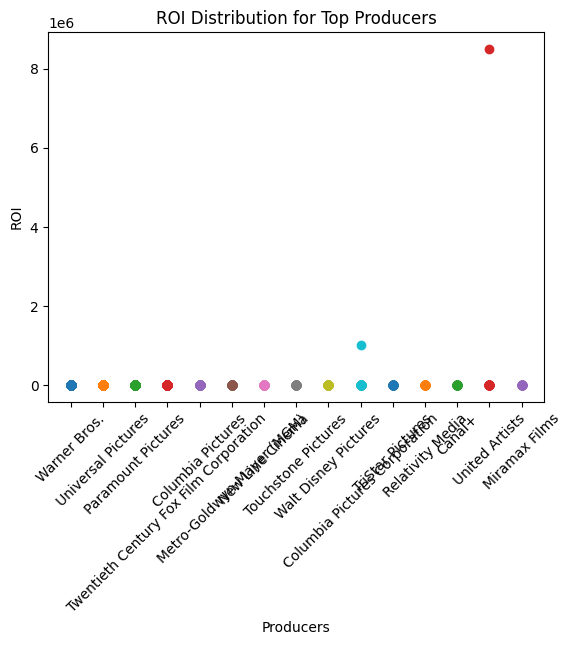

In [ ]:
#top 15 producers by number of movies
top_producers_list = producer_df["producer"].value_counts().head(15).index

filtered_df = producer_df[producer_df["producer"].isin(top_producers_list)]

plt.figure()
for producer in top_producers_list:
    subset = filtered_df[filtered_df["producer"] == producer]
    plt.scatter([producer]*len(subset), subset["roi"])

plt.title("ROI Distribution for Top Producers")
plt.xlabel("Producers")
plt.ylabel("ROI")
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure()
plt.scatter(df["budget"], df["roi"])
plt.xlabel("Budget")
plt.ylabel("ROI")
plt.title("Budget vs ROI")
plt.show()

**QUESTION 5**

**Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.**

In [ ]:
# Count actor appearances
all_actors = []
for cast_list in df["cast_parsed"]:
    all_actors.extend([person['name'] for person in cast_list])
actor_counts = Counter(all_actors)
top_actor = actor_counts.most_common(1)[0][0]
top_actor_count = actor_counts[top_actor]
print(f"ACTOR IN MOST MOVIES: {top_actor}")
print(f"Total movies: {top_actor_count}")
# Movies with this actor
actor_movies = []
for idx, row in df.iterrows():
    if any(person['name'] == top_actor for person in row["cast_parsed"]):
        actor_movies.append({
            'title': row['title'],
            'genres': [g['name'] for g in row["genres_parsed"]],
            'profit': row['profit'],
            'roi': row['roi']
        })
print(f"\nSummary for {top_actor}:")
print(pd.DataFrame(actor_movies)[['title', 'profit', 'roi']].describe())

ACTOR IN MOST MOVIES: Samuel L. Jackson
Total movies: 30

Summary for Samuel L. Jackson:
             profit        roi
count  3.000000e+01  30.000000
mean   2.265101e+08   2.302250
std    3.577368e+08   3.092706
min   -2.300937e+07  -0.610895
25%    1.404628e+07   0.000000
50%    5.022021e+07   1.066046
75%    2.216220e+08   3.815601
max    1.299558e+09  13.604762


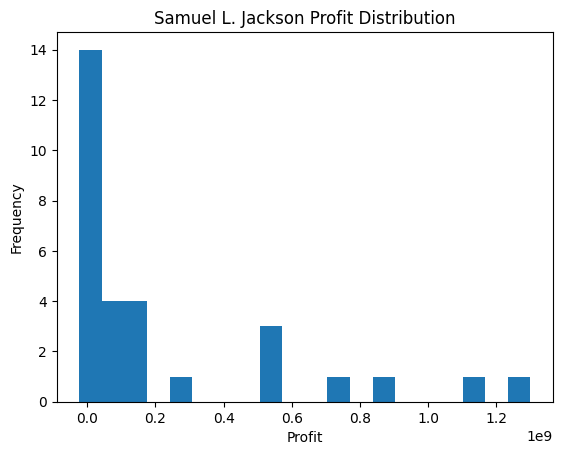

In [ ]:
actor_df = pd.DataFrame(actor_movies)

plt.figure()
plt.hist(actor_df["profit"], bins=20)
plt.title(f"{top_actor} Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Sample of original 'production_companies' column:")
print(df['production_companies'].head())
print("\nSample of parsed 'prod_companies' column:")
print(df['prod_companies'].head())


Sample of original 'production_companies' column:
0    [{'name': 'Paramount Pictures', 'id': 4}, {'na...
1          [{'name': 'Walt Disney Pictures', 'id': 2}]
2    [{'name': 'Bold Films', 'id': 2266}, {'name': ...
3                                                  NaN
4                                                  NaN
Name: production_companies, dtype: object

Sample of parsed 'prod_companies' column:
0    [{'name': 'Paramount Pictures', 'id': 4}, {'na...
1          [{'name': 'Walt Disney Pictures', 'id': 2}]
2    [{'name': 'Bold Films', 'id': 2266}, {'name': ...
3                                                   []
4                                                   []
Name: prod_companies, dtype: object


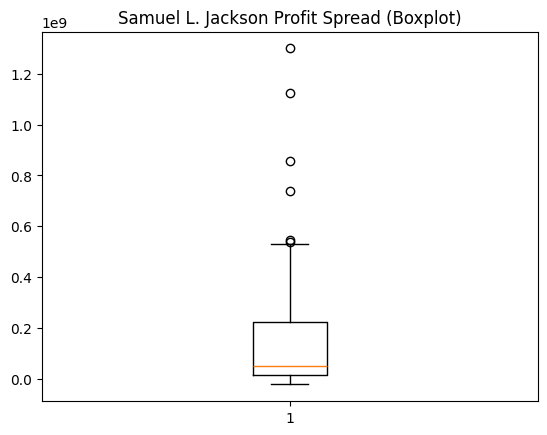

In [ ]:
plt.figure()
plt.boxplot(actor_df["profit"])
plt.title(f"{top_actor} Profit Spread (Boxplot)")
plt.show()

**QUESTION 6**

**Top 3 directors prefer which actors the most?**

In [ ]:
# Find top 3 directors by average ROI
director_roi = []
for idx, row in df.iterrows():
    director = next((person['name'] for person in row["crew_parsed"]
                    if person.get('job') == 'Director'), None)
    if director:
        director_roi.append({"director": director, "roi": row["roi"]})

director_df = pd.DataFrame(director_roi)
top_directors = (
    director_df.groupby("director")["roi"]
              .mean()
              .sort_values(ascending=False)
              .head(3)
)
print("TOP 3 DIRECTORS BY AVERAGE ROI & THEIR FAVORITE ACTORS:")
for director in top_directors.index:
    # Find actors they work with most
    director_actors = []
    for idx, row in df.iterrows():
        dir_name = next((p['name'] for p in row["crew_parsed"]
                        if p.get('job') == 'Director'), None)
        if dir_name == director:
            director_actors.extend([p['name'] for p in row["cast_parsed"]])
    actor_prefs = Counter(director_actors).most_common(3)
    print(f"\n{director}:")
    for actor, count in actor_prefs:
        print(f"  • {actor} ({count} movies)")

TOP 3 DIRECTORS BY AVERAGE ROI & THEIR FAVORITE ACTORS:

Park Kwang-hyun:
  • Jung Jae-young (1 movies)
  • Seo Jae-kyeong (1 movies)
  • Ryu Deok-hwan (1 movies)

Charlie Chaplin:
  • Charlie Chaplin (3 movies)
  • Paulette Goddard (2 movies)
  • Henry Bergman (2 movies)

Douglas Aarniokoski:
  • Paz de la Huerta (1 movies)
  • Katrina Bowden (1 movies)
  • Kathleen Turner (1 movies)


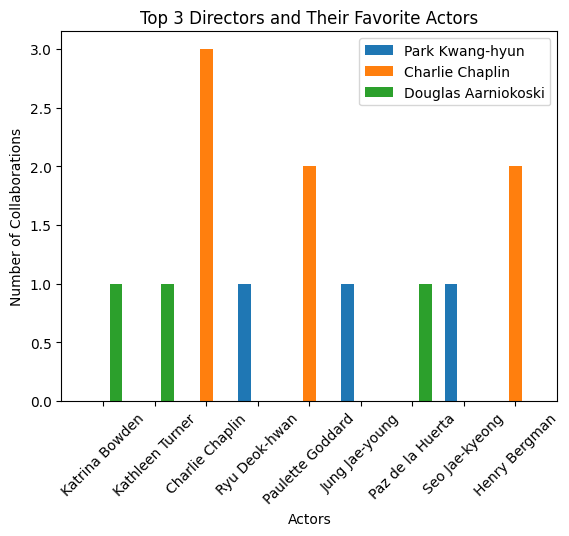

In [ ]:
# Prepare data
director_actor_data = {}

for director in top_directors.index:
    director_actors = []

    for idx, row in df.iterrows():
        dir_name = next((p['name'] for p in row["crew_parsed"]
                        if p.get('job') == 'Director'), None)
        if dir_name == director:
            director_actors.extend([p['name'] for p in row["cast_parsed"]])

    actor_prefs = Counter(director_actors).most_common(3)
    director_actor_data[director] = dict(actor_prefs)

# Get all unique actors across 3 directors
all_actors = list(set(
    actor for actors in director_actor_data.values() for actor in actors
))

# Create matrix for plotting
data_matrix = []
for director in director_actor_data:
    counts = []
    for actor in all_actors:
        counts.append(director_actor_data[director].get(actor, 0))
    data_matrix.append(counts)

# Plot
x = np.arange(len(all_actors))
width = 0.25

plt.figure()

for i, director in enumerate(director_actor_data.keys()):
    plt.bar(x + i*width, data_matrix[i], width, label=director)

plt.xticks(x + width, all_actors, rotation=45)
plt.xlabel("Actors")
plt.ylabel("Number of Collaborations")
plt.title("Top 3 Directors and Their Favorite Actors")
plt.legend()

plt.show()